# Netflis_project

In [1]:
# import liberlies
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Import Data form csv file

In [2]:
import pandas as pd

df = pd.read_csv('C:\\Users\\Administrator\\Downloads\\netflix.csv')
df.head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,12/15/2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,3/1/2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2/25/2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,11/24/2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,12/22/2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [4]:
df.duplicated().sum()

0

In [5]:
# FIRST STEP IS CHANGES STRING TO
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'],errors='coerce')


df['Vote_Count'] = df['Vote_Count'].fillna(0)

#THIRTH STEP

df['Vote_Count'] = df['Vote_Count'].astype('int64')


# step 2 changes the values of FLOAT

df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# step Second
df['Vote_Average'] = df['Vote_Average'].astype('float64')

In [6]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9837.000000,9826.000000
mean,40.320570,1391.386093,6.439467
std,108.874308,2610.258502,1.129797
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,443.000000,6.500000
75%,35.174500,1375.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [7]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Release_Date'] = df['Release_Date'].fillna(pd.Timestamp('2015-01-01'))
# step2

print(df['Release_Date'].dtype)

df['Release_Date'] = df['Release_Date'].dt.year

df['Release_Date'].dtype

datetime64[ns]


dtype('int32')

In [8]:
df.head(1)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...


# Dropping the columns

In [9]:
cols = ['Overview','Original_Language',"Poster_Url"]

df.drop(cols , axis = 1 , inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [10]:
df.head(1)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"


Categorizing vote_Average columns

we would cut the Vote_Average values and make 4 categorical popular average below_avg not_populuer to describe it more using catigorize_col() function provided above




In [15]:
def catigorical_col(df,col,labels):
    
    edges =[df[col].describe()['min'],
            df[col].describe()['25%'],
            df[col].describe()['50%'],
            df[col].describe()['75%'],
            df[col].describe()['max']]
    df[col] = pd.cut(df[col],edges,labels = labels ,duplicates= 'drop')
    return df

In [16]:
labels = ['not_populaar','below_avg','average','popular']

catigorical_col(df,'Vote_Average',labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_populaar', NaN]
Categories (4, object): ['not_populaar' < 'below_avg' < 'average' < 'popular']

In [17]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [21]:
(df['Vote_Average'] =="popular").sum()

2450

In [22]:
# count how many movies get victory 
df['Vote_Average'].value_counts()

Vote_Average
not_populaar    2467
popular         2450
average         2411
below_avg       2398
Name: count, dtype: int64

In [24]:
# Drop NAN values of our dataset

df.dropna(inplace=True)


# check in remove

df.isnull().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [29]:
len(df['Genre'],axis = 1)

TypeError: len() takes no keyword arguments

In [35]:
df['Genre'].str.len().head(5)

0    34
1    24
2     8
3    34
4    32
Name: Genre, dtype: int64

#WE'd split genres into a list and then ecplode our dataframe to have only one genre per row for each movie


In [36]:
df['Genre'] = df['Genre'].str.split(", ")

df = df.explode('Genre').reset_index(drop=True)

df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [37]:
# casting columsn into category

df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25551 non-null  int32   
 1   Title         25551 non-null  object  
 2   Popularity    25551 non-null  float64 
 3   Vote_Count    25551 non-null  int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25551 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


# Data Visualization


In [39]:
sns.set_style('whitegrid')

# Q1. What is the most popular genre in movies released on NetfliX


In [41]:
df['Genre'].describe()

count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

<Figure size 1200x1200 with 0 Axes>

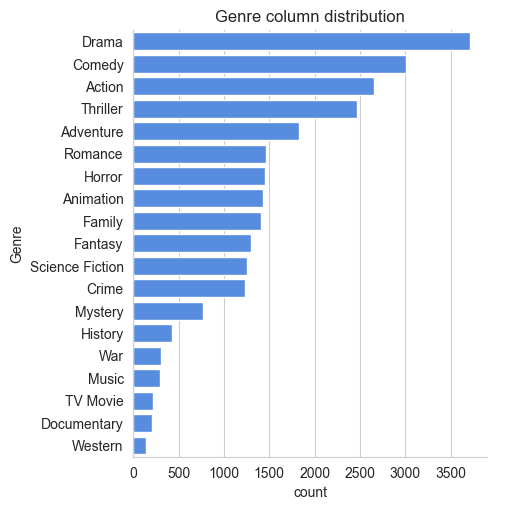

In [47]:
plt.figure(figsize =(12,12))
sns.catplot(data = df ,y = 'Genre', kind = "count",order=df['Genre'].value_counts().index, color = '#4287f5')

plt.title("Genre column distribution")

plt.show()

# Q1. What is the most popular genre in movies released on NetfliX



C:\Users\Administrator\AppData\Local\Temp\ipykernel_8756\1552038338.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data =df , x = 'Vote_Average', y = 'Vote_Count', palette='viridis')


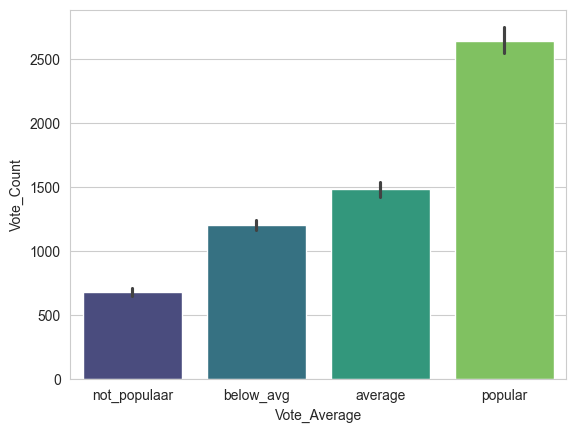

In [49]:
sns.barplot(data =df , x = 'Vote_Average', y = 'Vote_Count', palette='viridis',)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8756\771973712.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data = df, y = 'Vote_Average', kind = 'count', palette='viridis',


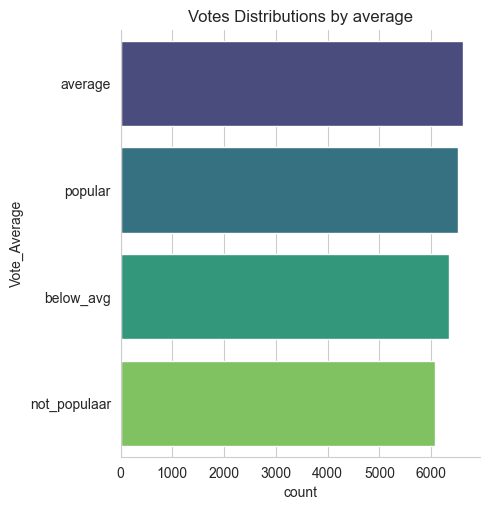

In [52]:
sns.catplot(data = df, y = 'Vote_Average', kind = 'count', palette='viridis',
            order = df['Vote_Average'].value_counts().index)
plt.title("Votes Distributions by average")
plt.show()

In [53]:
df['Vote_Average'].describe()

count       25551
unique          4
top       average
freq         6612
Name: Vote_Average, dtype: object

# what movies got the lowest popularity? what's its genre?


In [1]:
df[df['Popularity'] == df['Popularity'].min()]

NameError: name 'df' is not defined

---
# what movies got the highest popularity? what's its genre?

In [59]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


# which year has the most filmmed movies?


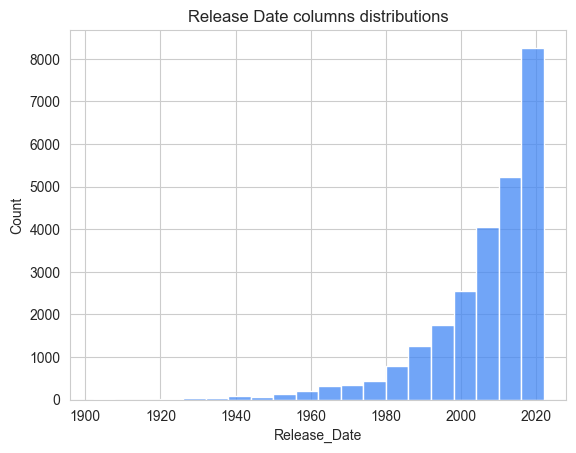

In [64]:
sns.histplot(data = df , x = df['Release_Date'], bins = 20, color = '#4287f5')
plt.title("Release Date columns distributions")
plt.show()

---
## Calnculison :- The most movies are Releses_year is 2020 because this year in make lot of movies releses
